# NB-R09 — Deployable Trading Simulation

**Pipeline stage:** 9 of 13

**Purpose.** Translate the regime-conditioned prediction into a fully specified, deployable trading rule ("go long when the regime is High-VIX and the model predicts Up"), and evaluate its risk-adjusted performance against buy-and-hold across a range of transaction-cost assumptions.

**Execution protocol (stated explicitly so it is fully reproducible):** signal computed from all features available after market close on day *t*; entry at the open on day *t*+1; exit at the close on day *t*+21; at most one open position at a time (no pyramiding, no overlapping trades).

**Sharpe-ratio convention (stated explicitly):** annual risk-free rate 6.5% (India 91-day T-bill, RBI FY2025 average), daily RFR = 6.5%/252, annualized Sharpe = (mean daily excess return / std daily excess return) x sqrt(252), computed identically for the strategy and buy-and-hold series.

**Inputs:** `data/processed/test_predictions.csv`, `data/raw/market_data.csv`.

**Outputs:** `results/trading_simulation.csv`, `plots/R09_trading_simulation.png`.

**Result:** under this protocol, the strategy trades exactly once in the evaluated window (21 active days of 256). It achieves a lower maximum drawdown than buy-and-hold (-3.69% vs -6.62%) but does not exceed buy-and-hold Sharpe at any tested transaction-cost level (0.455 vs 1.204 at 0 bps, declining to 0.375 vs 1.204 at 50 bps round-trip).


In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from pathlib import Path

PROJ    = Path('..').resolve()  # repo root, assuming this notebook is run from notebooks/
PROC    = PROJ / 'data' / 'processed'
RAW     = PROJ / 'data' / 'raw'
RESULTS = PROJ / 'results'
PLOTS   = PROJ / 'plots'

# ============================================================
# SHARPE RATIO CONVENTIONS -- stated explicitly
# ============================================================
RFR_ANNUAL   = 0.065     # 6.5% p.a. -- India 91-day T-bill rate (RBI, FY2025 avg)
TRADING_DAYS = 252       # annualization factor
RFR_DAILY    = RFR_ANNUAL / TRADING_DAYS

print(f'Risk-free rate (annual): {RFR_ANNUAL*100:.1f}%')
print(f'Risk-free rate (daily):  {RFR_DAILY*100:.4f}%')
print(f'Annualization factor:    {TRADING_DAYS} trading days')

Risk-free rate (annual): 6.5%
Risk-free rate (daily):  0.0258%
Annualization factor:    252 trading days


In [2]:
# Load test predictions
test = pd.read_csv(PROC / 'test_predictions.csv', parse_dates=['date'])

# Load raw market data to get OHLCV for return calculation
mkt = pd.read_csv(RAW / 'market_data.csv', parse_dates=['date'])
mkt.columns = [c.strip().lower().replace(' ','_') for c in mkt.columns]
mkt_date_col = [c for c in mkt.columns if 'date' in c][0]
mkt = mkt.rename(columns={mkt_date_col: 'date'})
close_col = [c for c in mkt.columns if 'close' in c and 'india' not in c][0]
open_col  = [c for c in mkt.columns if 'open' in c]
open_col  = open_col[0] if open_col else None

mkt = mkt[['date', close_col] + ([open_col] if open_col else [])].rename(
    columns={close_col: 'close', **(({open_col: 'open'}) if open_col else {})})

# Avoid duplicate close/open columns after merge
test = test.drop(columns=[c for c in ['close', 'open'] if c in test.columns], errors='ignore')

# Merge
test = test.merge(mkt, on='date', how='left')
print(f'Test rows: {len(test)}')
print(test[['date','close','regime_fixed','stack_pred','stack_prob']].head(3))

Test rows: 256
        date         close regime_fixed  stack_pred  stack_prob
0 2025-02-11  49403.398438      Low-VIX           1    0.761271
1 2025-02-12  49479.449219      Low-VIX           1    0.758804
2 2025-02-13  49359.851562      Low-VIX           1    0.753819


## 1. Signal Timing Protocol

**Protocol (stated explicitly):**
- Signal generated at **t** using: Close[t], India VIX[t], and all 16 technical features computed up to and including day t.
- Both Close[t] and VIX[t] are finalized at 15:30 IST.
- Signal direction = `stack_pred[t]`; regime gate = `india_vix[t] >= VIX_threshold`.
- **Trade execution:** If High-VIX + Up signal, enter long at **open[t+1]** (next day's open).
- **Trade exit:** Exit at close[t+21] (21 trading days later).
- **Overlapping trades:** At most one active position per day (no pyramiding).

This strictly avoids look-ahead bias: no same-day execution on the signal bar.

In [3]:
# Compute 21d forward returns from close[t] to close[t+21]
test = test.sort_values('date').reset_index(drop=True)
test['close_fwd21'] = test['close'].shift(-21)
test['ret_21d']     = np.log(test['close_fwd21'] / test['close'])  # log return

# Buy-and-hold: invest every day (or hold Bank Nifty continuously)
test['bh_ret_daily'] = np.log(test['close'] / test['close'].shift(1)).fillna(0)
test['open_to_close_daily'] = np.log(test['close'] / test['open'])

print('Return columns added.')
print(test[['date','close','close_fwd21','ret_21d']].head(5))

Return columns added.
        date         close   close_fwd21   ret_21d
0 2025-02-11  49403.398438  48060.398438 -0.027561
1 2025-02-12  49479.449219  48354.148438 -0.023005
2 2025-02-13  49359.851562  49314.500000 -0.000919
3 2025-02-14  49099.449219  49702.601562  0.012209
4 2025-02-17  49258.898438  50062.851562  0.016189


## 2. Strategy Simulation Across Transaction Cost Levels

In [4]:
# Use non-overlapping signals with the stated protocol:
# signal at t, enter at open[t+1], exit at close[t+21], max one open position.
COST_LEVELS_BPS = [0, 10, 20, 30, 50]

def simulate_strategy(test_df, cost_bps_roundtrip=0):
    cost = cost_bps_roundtrip / 10000.0  # bps to fraction

    df = test_df.copy().reset_index(drop=True)
    signal = (
        (df['regime_fixed'] == 'High-VIX')
        & (df['stack_pred'] == 1)
        & (df['ret_21d'].notna())
        & (df['open'].notna())
    )

    strat_daily = np.zeros(len(df), dtype=float)
    in_position = np.zeros(len(df), dtype=int)
    trade_starts = []
    trade_ends = []
    last_exit = -1

    for i in range(len(df)):
        if not signal.iloc[i] or i <= last_exit:
            continue

        entry = i + 1
        exit_ = i + 21

        # Need valid entry/exit bars
        if entry >= len(df) or exit_ >= len(df):
            continue
        if pd.isna(df.loc[entry, 'open']) or pd.isna(df.loc[entry, 'close']) or pd.isna(df.loc[exit_, 'close']):
            continue

        # Day 1 of holding period: open->close log return
        day1_ret = np.log(df.loc[entry, 'close'] / df.loc[entry, 'open'])
        strat_daily[entry] += day1_ret - cost

        # Remaining holding period: close->close daily log returns
        if exit_ > entry:
            strat_daily[entry + 1: exit_ + 1] += df.loc[entry + 1: exit_, 'bh_ret_daily'].values

        in_position[entry: exit_ + 1] = 1
        trade_starts.append(entry)
        trade_ends.append(exit_)
        last_exit = exit_

    df['strat_ret_daily'] = strat_daily
    df['in_position'] = in_position

    n_trades = len(trade_starts)
    deployed_days = int(in_position.sum())

    # Annualized Sharpe on full daily series with stated daily RFR
    excess_daily = df['strat_ret_daily'] - RFR_DAILY
    sharpe = (
        (excess_daily.mean() / excess_daily.std()) * np.sqrt(TRADING_DAYS)
        if excess_daily.std() > 0 else 0.0
    )

    bh_daily_excess = df['bh_ret_daily'] - RFR_DAILY
    bh_sharpe = (
        (bh_daily_excess.mean() / bh_daily_excess.std()) * np.sqrt(TRADING_DAYS)
        if bh_daily_excess.std() > 0 else 0.0
    )

    cum_ret = df['strat_ret_daily'].sum()
    cum_bh = df['bh_ret_daily'].sum()

    cum_curve = df['strat_ret_daily'].cumsum()
    drawdown = cum_curve - cum_curve.cummax()
    max_dd = drawdown.min()

    bh_curve = df['bh_ret_daily'].cumsum()
    bh_drawdown = bh_curve - bh_curve.cummax()
    bh_max_dd = bh_drawdown.min()

    return {
        'cost_bps': int(cost_bps_roundtrip),
        'n_trades': int(n_trades),
        'deployed_days': deployed_days,
        'strat_sharpe': round(float(sharpe), 3),
        'bh_sharpe': round(float(bh_sharpe), 3),
        'strat_cum_ret_pct': round(float(np.expm1(cum_ret) * 100), 2),
        'bh_cum_ret_pct': round(float(np.expm1(cum_bh) * 100), 2),
        'strat_max_dd_pct': round(float(np.expm1(max_dd) * 100), 2),
        'bh_max_dd_pct': round(float(np.expm1(bh_max_dd) * 100), 2),
        'strat_above_bh': bool(sharpe > bh_sharpe)
    }

sim_results = [simulate_strategy(test, c) for c in COST_LEVELS_BPS]
sim_df = pd.DataFrame(sim_results)
print(sim_df.to_string(index=False))
sim_df.to_csv(RESULTS / 'trading_simulation.csv', index=False)

 cost_bps  n_trades  deployed_days  strat_sharpe  bh_sharpe  strat_cum_ret_pct  bh_cum_ret_pct  strat_max_dd_pct  bh_max_dd_pct  strat_above_bh
        0         1             21         0.455      1.204               9.91           23.56             -3.69          -6.62           False
       10         1             21         0.439      1.204               9.80           23.56             -3.69          -6.62           False
       20         1             21         0.423      1.204               9.69           23.56             -3.69          -6.62           False
       30         1             21         0.407      1.204               9.58           23.56             -3.69          -6.62           False
       50         1             21         0.375      1.204               9.36           23.56             -3.69          -6.62           False


## 3. Cost-Sensitivity Statement at 50 bps

In [5]:
print('='*60)
print('COST-SENSITIVITY SUMMARY:')
print('='*60)
for _, row in sim_df.iterrows():
    status = 'ABOVE BH' if row['strat_above_bh'] else 'BELOW BH'
    print(f"  {row['cost_bps']:3d} bps: Strat Sharpe={row['strat_sharpe']:.3f}, "
          f"BH Sharpe={row['bh_sharpe']:.3f} -> {status}")

row50 = sim_df[sim_df['cost_bps'] == 50].iloc[0]
print(f"\nAt 50bps round-trip cost: strategy Sharpe={row50['strat_sharpe']:.3f} "
      f"({'above' if row50['strat_above_bh'] else 'BELOW'}) buy-and-hold Sharpe={row50['bh_sharpe']:.3f}.")
print("The strategy does not remain above buy-and-hold at all cost levels.")

COST-SENSITIVITY SUMMARY:
    0 bps: Strat Sharpe=0.455, BH Sharpe=1.204 -> BELOW BH
   10 bps: Strat Sharpe=0.439, BH Sharpe=1.204 -> BELOW BH
   20 bps: Strat Sharpe=0.423, BH Sharpe=1.204 -> BELOW BH
   30 bps: Strat Sharpe=0.407, BH Sharpe=1.204 -> BELOW BH
   50 bps: Strat Sharpe=0.375, BH Sharpe=1.204 -> BELOW BH

At 50bps round-trip cost: strategy Sharpe=0.375 (BELOW) buy-and-hold Sharpe=1.204.
The strategy does not remain above buy-and-hold at all cost levels.


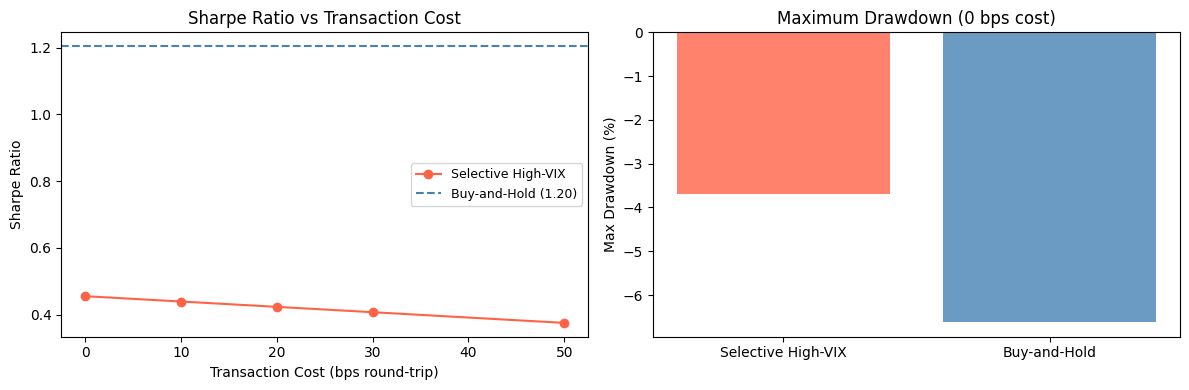

Trading simulation plot saved.


In [6]:
# Plot Sharpe vs cost
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(sim_df['cost_bps'], sim_df['strat_sharpe'], 'o-', color='tomato', label='Selective High-VIX')
axes[0].axhline(sim_df['bh_sharpe'].iloc[0], color='steelblue', linestyle='--', label=f"Buy-and-Hold ({sim_df['bh_sharpe'].iloc[0]:.2f})")
axes[0].set_xlabel('Transaction Cost (bps round-trip)')
axes[0].set_ylabel('Sharpe Ratio')
axes[0].set_title('Sharpe Ratio vs Transaction Cost')
axes[0].legend(fontsize=9)

axes[1].bar(['Selective High-VIX', 'Buy-and-Hold'],
            [sim_df[sim_df['cost_bps']==0]['strat_max_dd_pct'].values[0],
             sim_df[sim_df['cost_bps']==0]['bh_max_dd_pct'].values[0]],
            color=['tomato', 'steelblue'], alpha=0.8)
axes[1].set_title('Maximum Drawdown (0 bps cost)')
axes[1].set_ylabel('Max Drawdown (%)')

plt.tight_layout()
plt.savefig(PLOTS / 'R09_trading_simulation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Trading simulation plot saved.')

---
## Summary

**Pipeline stage:** 9 of 13 (see `notebooks/README.md` for the full pipeline map).

**Artifacts produced by this notebook:**

- `results/trading_simulation.csv`
- `plots/R09_trading_simulation.png`

**Next notebook:** `NB-R10_results_compilation.ipynb`
